# ZQE vs R `gllvm` — Poisson loadings recovery

A clean, **single-dataset** comparison of three estimators of a Poisson GLLVM
loading matrix $W$ ($q$ latent factors, $p$ responses), all fit to the *same*
simulated data and scored by the same metric.

| # | Method | Encoder (E-step) | Decoder statistic $T(y)$ |
|---|--------|------------------|--------------------------|
| 1 | **ZQE — Poisson MAP**  | exact Poisson–Newton MAP (`MapEncoderPoissonNewton`)   | `log1p` |
| 2 | **ZQE — Gaussian MAP** | closed-form Gaussian–log1p MAP (`MapEncoderGaussianLog1p`) | `log1p` |
| 3 | **R `gllvm` (VA)**     | variational approximation (Niku et al., via `gllvm.RGllvm`) | — (maximum likelihood) |

Both ZQE arms share the **same** `PoissonGLM(T=log1p)` decoder and the same
`ZQEAutoFitter` recipe — *only the encoder differs*. The R baseline is called
through the `gllvm.RGllvm` wrapper (a thin subprocess bridge to R's `gllvm()`).
All three are scored by the relative orthogonal **Procrustes error**
(`procrustes_error`, rotation-only and scale-free). The **Diagnostics** section
below opens up the ZQE fit so you can watch it converge.

In [15]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from gllvm.gllvm_module import GLLVM
from gllvm.glms import PoissonGLM
from gllvm.encoder import MapEncoderPoissonNewton, MapEncoderGaussianLog1p
from gllvm.autofit import ZQEAutoFitter, orthogonal_align, procrustes_error
from gllvm.r_gllvm import RGllvm
from gllvm.simulations import make_sparse, simulate
from gllvm import diagnostics as dg

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda


## Simulation

One dense Poisson GLLVM: every latent factor loads on every response.

In [ ]:
NL  = 2      # latent dimension q
NR  = 20     # responses p
NS  = 100    # observations n
WZS = 0.3    # loading scale

# Generate on CPU so the dataset is identical on any machine: the torch RNG
# stream differs between CPU and CUDA, and a heavier-tailed CUDA draw can fall
# into a spurious root of the Poisson-MAP estimating equation. Fit on DEV.
torch.manual_seed(12345)
g_true   = make_sparse(n_latent=NL, poisson=NR, active_latent=NL,
                       wz_scale=WZS, responses_per_latent=NR)
Y_cpu, Z = simulate(g_true, n_samples=NS, device="cpu")
W_true   = g_true.wz.detach()        # CPU; used only for scoring
Y        = Y_cpu.to(DEV)             # counts to fit on

print(f"p={g_true.p}  q={NL}  n={NS}   y in [{Y.min():.0f}, {Y.max():.0f}]   "
      f"non-zero loadings / column = {(W_true != 0).sum(0).tolist()}")

p=20  q=1  n=100   y in [0, 24]   non-zero loadings / column = [20]


In [17]:
next(g_true.parameters())

Parameter containing:
tensor([[-0.2032],
        [ 0.0213],
        [-0.1375],
        [ 0.5054],
        [-0.1979],
        [-0.4199],
        [-0.2056],
        [-0.0120],
        [ 0.4633],
        [ 0.3515],
        [-0.1141],
        [ 0.5201],
        [ 0.2620],
        [ 0.3010],
        [ 0.4585],
        [ 0.1436],
        [-0.3967],
        [-0.0757],
        [-0.6263],
        [-0.1720]], requires_grad=True)

## ZQE fits

Both arms use the identical random decoder init (we reseed before each), so the
**encoder is the only difference**. Because the ZQE estimating equation obeys the
score-function identity, the encoder affects *efficiency*, not consistency — the
parameter-free encoders track $\theta$ automatically and are unbiased from random init.

In [18]:
def fresh_decoder():
    """Fresh dense Poisson decoder with ZQE statistic T(y)=log1p.

    Random init, no knowledge of the true loadings. Sampling / log_prob are
    unchanged by T — it only sets the ZQE estimating function.
    """
    g = GLLVM(latent_dim=NL, output_dim=NR, bias=True).to(DEV)
    # g.add_glm(PoissonGLM, idx=list(range(NR)), name="P")
    g.add_glm(PoissonGLM, idx=list(range(NR)), params={"T": torch.log1p}, name="P")
    # g.add_glm(PoissonGLM, idx=list(range(NR)), params={"T": lambda x: 2*torch.sqrt(x + 3./8.)})
    with torch.no_grad():
        nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)
    return g

# Same decoder, two parameter-free encoders (each holds a live reference to its
# decoder, so it always uses the current W, b).
ENC_FACTORIES = {
    # "ZQE — Poisson MAP":  lambda g: MapEncoderPoissonNewton(g, lam=1.0, max_iter=30),
    "ZQE — Gaussian MAP": lambda g: MapEncoderGaussianLog1p(g)
}

zqe = {}
for name, enc_factory in ENC_FACTORIES.items():
    torch.manual_seed(SEED)                  # identical decoder init across arms
    g  = fresh_decoder()
    ft = ZQEAutoFitter(g, encoder_factory=enc_factory, device=DEV, seed=SEED,
                       steps_per_round=150, max_rounds=10, tol=0.001,
                       refine_lr=.5, verbose=False, warmup_lr=.5, ema_decay=.95)
    ft.fit(Y)
    zqe[name] = ft
    print(f"{name:<22} Procrustes={procrustes_error(W_true, ft.model.wz):.4f}   "
          f"change={ft.change_:.4f}   converged={ft.converged_}")

ZQE — Gaussian MAP     Procrustes=0.4769   change=0.0006   converged=True


## Diagnostics — watch the fit behave

The headline check is the **objective fluctuating about 0**. The ZQE loss is
$-(m_1-m_2)$, the (negated) empirical estimating equation; at a root $m_1=m_2$.
After warm-up drives it down, the refinement heads should scatter about 0 — a
*biased* optimiser would settle off-zero. `gllvm.diagnostics` reads each fitter's
recorded `.history`:

- `plot_objective` — objective over warm-up + refinement (0 = target root)
- `plot_lr` — learning-rate schedule (anneal, then constant per-round refine LR)
- `plot_gradnorm` — gradient norm (should decay)
- `plot_heads` — cross-head dispersion vs `tol` (mixing / convergence)
- `plot_grad_balance` — tail-averaged loading gradient (estimating equation $\approx 0$)
- `plot_params` — trajectories of random loadings (dashed = true values)
- `plot_deviance` — Poisson deviance / observation over iterations
- `plot_diagnostics` — all of them in one dashboard

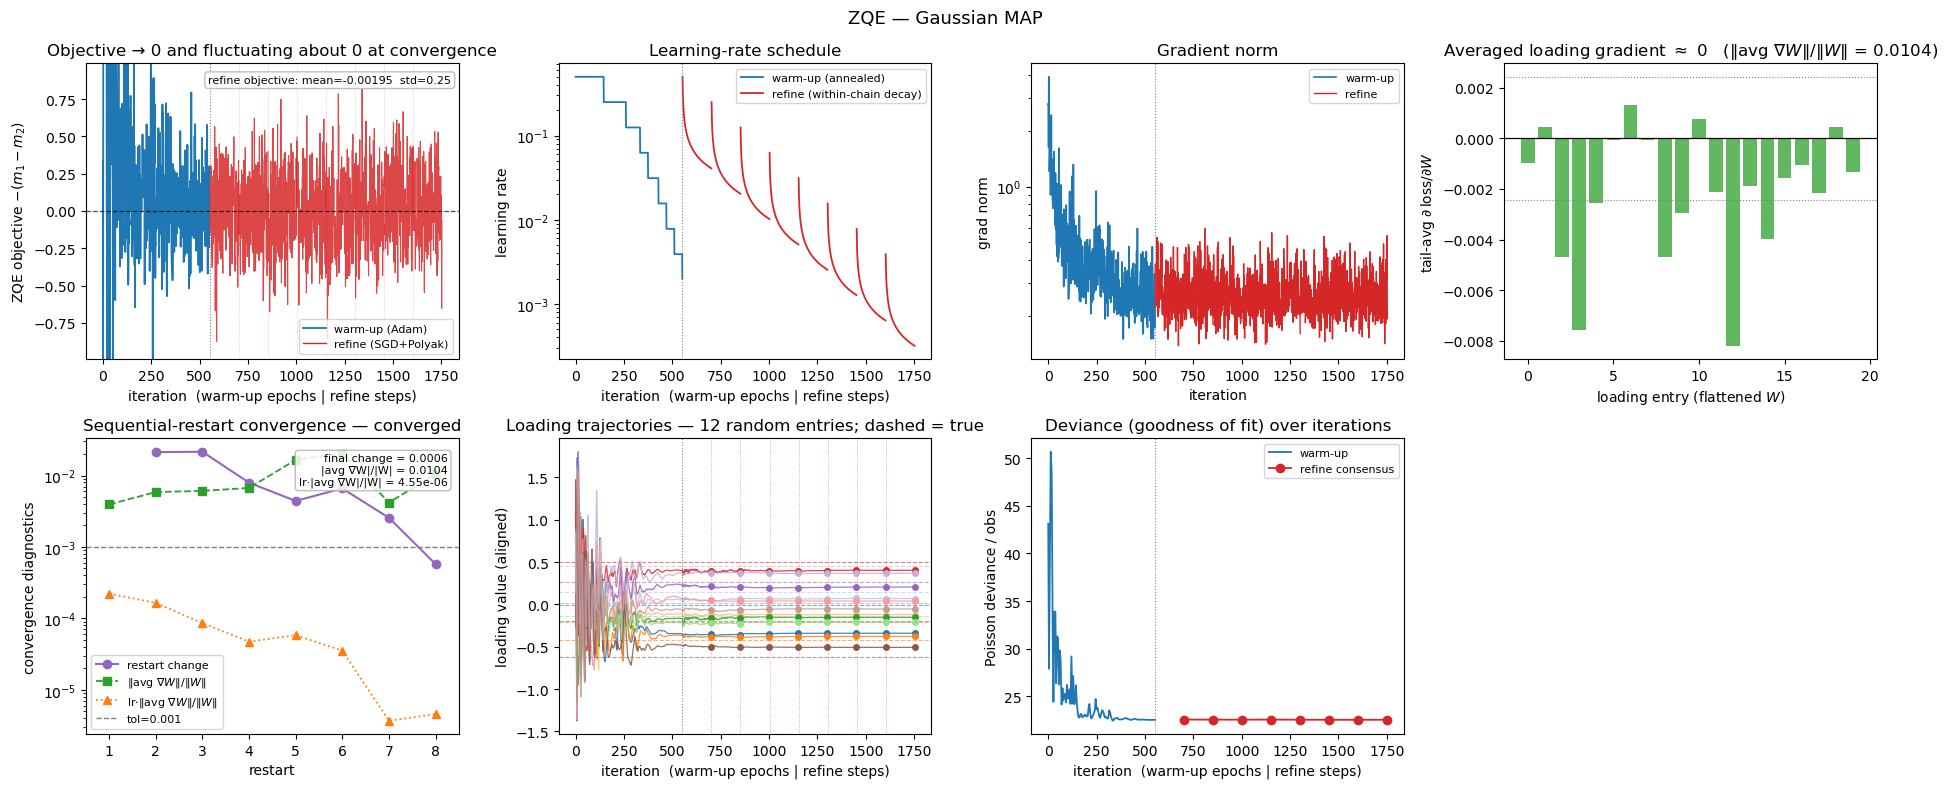

In [19]:
# Full dashboard per ZQE arm
for name, ft in zqe.items():
    dg.plot_diagnostics(ft, g_true=g_true, title=name)
    plt.show()

## R `gllvm` baseline

Called through the `gllvm.RGllvm` wrapper. Defaults target a WSL2 → Windows-R
setup; for a native install pass `RGllvm(rscript="Rscript", workdir="/tmp/...")`.
If R is unavailable the cell skips cleanly so the rest of the notebook still runs.

In [20]:
r = RGllvm(method="VA", family="poisson")

if r.available():
    r_fit      = r.fit(Y.cpu().numpy(), num_lv=NL, seed=SEED)
    r_loadings = r_fit.loadings
    print(f"R gllvm (VA)           Procrustes={procrustes_error(W_true, r_loadings):.4f}")
else:
    r_loadings = None
    print(f"Rscript not found at {r.rscript!r} — skipping R baseline "
          f"(pass rscript=... / workdir=... to enable).")

R gllvm (VA)           Procrustes=0.4313


## Results

Method                   Procrustes    Restart Δ
------------------------------------------------
ZQE — Gaussian MAP           0.4769       0.0006
R gllvm (VA)                 0.4313            —


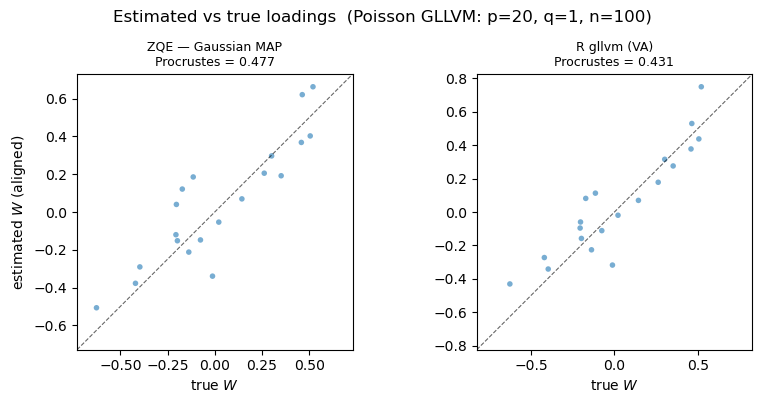

In [21]:
# Procrustes table
methods = [(name, ft.model.wz, ft.change_) for name, ft in zqe.items()]
if r_loadings is not None:
    methods.append(("R gllvm (VA)", r_loadings, float("nan")))

print(f"{'Method':<22}{'Procrustes':>13}{'Restart Δ':>13}")
print("-" * 48)
for name, W_hat, disp in methods:
    disp_str = f"{disp:.4f}" if disp == disp else "—"     # nan -> —
    print(f"{name:<22}{procrustes_error(W_true, W_hat):>13.4f}{disp_str:>13}")


# Loadings scatter: true vs Procrustes-aligned estimate
def align_to_true(W_hat):
    Wt = W_true.detach().to("cpu", torch.float64)
    We = (W_hat.detach() if isinstance(W_hat, torch.Tensor)
          else torch.as_tensor(np.asarray(W_hat))).to("cpu", torch.float64)
    return (We @ orthogonal_align(Wt, We)).numpy()

Wt_np = W_true.cpu().numpy()
fig, axes = plt.subplots(1, len(methods), figsize=(4.2 * len(methods), 4.0),
                         squeeze=False)
fig.suptitle(f"Estimated vs true loadings  (Poisson GLLVM: p={NR}, q={NL}, n={NS})")
for ax, (name, W_hat, _) in zip(axes[0], methods):
    W_al = align_to_true(W_hat)
    ax.scatter(Wt_np.ravel(), W_al.ravel(), s=16, alpha=0.6, edgecolors="none")
    lim = 1.1 * max(np.abs(Wt_np).max(), np.abs(W_al).max())
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.6)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.set_title(f"{name}\nProcrustes = {procrustes_error(W_true, W_hat):.3f}", fontsize=9)
    ax.set_xlabel("true $W$")
axes[0][0].set_ylabel("estimated $W$ (aligned)")
plt.tight_layout(); plt.show()